In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../STOCK MARKET/BPCL.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,BPCL,EQ,381.20,405.00,407.00,393.05,397.75,399.25,399.32,8720,3.482029e+11,NaN,NaN,NaN
1,2000-01-04,BPCL,EQ,399.25,397.75,397.75,367.40,377.45,370.50,375.71,22820,8.573699e+11,NaN,NaN,NaN
2,2000-01-05,BPCL,EQ,370.50,350.00,385.00,350.00,360.10,359.95,359.96,152538,5.490785e+12,NaN,NaN,NaN
3,2000-01-06,BPCL,EQ,359.95,362.00,384.00,362.00,381.65,380.30,380.10,59554,2.263623e+12,NaN,NaN,NaN
4,2000-01-07,BPCL,EQ,380.30,369.00,390.00,366.00,381.50,379.85,378.33,43187,1.633890e+12,NaN,NaN,NaN


In [4]:
df.tail()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
5301,2021-04-26,BPCL,EQ,423.05,426.0,428.35,417.55,417.60,418.90,421.33,6444098,2.715060e+14,68579.0,2408600.0,0.3738
5302,2021-04-27,BPCL,EQ,418.90,417.5,423.10,416.55,420.00,420.35,420.45,5408165,2.273853e+14,45282.0,2300523.0,0.4254
5303,2021-04-28,BPCL,EQ,420.35,422.0,424.35,414.90,417.15,417.50,419.33,9902533,4.152459e+14,59529.0,5176820.0,0.5228
5304,2021-04-29,BPCL,EQ,417.50,422.0,423.00,417.00,419.00,419.55,420.00,6632804,2.785775e+14,64676.0,2976829.0,0.4488
5305,2021-04-30,BPCL,EQ,419.55,417.5,437.50,414.65,422.10,421.80,428.14,16851470,7.214724e+14,195429.0,6453804.0,0.3830


In [5]:
df.isnull().sum()

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
%Deliverble            509
dtype: int64

In [10]:
df['Trades'].fillna(df['Trades'].median(), inplace=True)
df['Deliverable Volume'].fillna(df['Deliverable Volume'].median(), inplace=True)
df['%Deliverble'].fillna(df['%Deliverble'].median(), inplace=True)

In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                5306 non-null   datetime64[ns]
 1   Symbol              5306 non-null   object        
 2   Series              5306 non-null   object        
 3   Prev Close          5306 non-null   float64       
 4   Open                5306 non-null   float64       
 5   High                5306 non-null   float64       
 6   Low                 5306 non-null   float64       
 7   Last                5306 non-null   float64       
 8   Close               5306 non-null   float64       
 9   VWAP                5306 non-null   float64       
 10  Volume              5306 non-null   int64         
 11  Turnover            5306 non-null   float64       
 12  Trades              5306 non-null   float64       
 13  Deliverable Volume  5306 non-null   float64     

In [17]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,BPCL,EQ,381.20,405.00,407.00,393.05,397.75,399.25,399.32,8720,3.482029e+11,45158.5,443175.0,0.4438
1,2000-01-04,BPCL,EQ,399.25,397.75,397.75,367.40,377.45,370.50,375.71,22820,8.573699e+11,45158.5,443175.0,0.4438
2,2000-01-05,BPCL,EQ,370.50,350.00,385.00,350.00,360.10,359.95,359.96,152538,5.490785e+12,45158.5,443175.0,0.4438
3,2000-01-06,BPCL,EQ,359.95,362.00,384.00,362.00,381.65,380.30,380.10,59554,2.263623e+12,45158.5,443175.0,0.4438
4,2000-01-07,BPCL,EQ,380.30,369.00,390.00,366.00,381.50,379.85,378.33,43187,1.633890e+12,45158.5,443175.0,0.4438


In [18]:
df['Next_Close'] = df.groupby('Symbol')['Close'].shift(-1)

In [19]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Next_Close
0,2000-01-03,BPCL,EQ,381.20,405.00,407.00,393.05,397.75,399.25,399.32,8720,3.482029e+11,45158.5,443175.0,0.4438,370.50
1,2000-01-04,BPCL,EQ,399.25,397.75,397.75,367.40,377.45,370.50,375.71,22820,8.573699e+11,45158.5,443175.0,0.4438,359.95
2,2000-01-05,BPCL,EQ,370.50,350.00,385.00,350.00,360.10,359.95,359.96,152538,5.490785e+12,45158.5,443175.0,0.4438,380.30
3,2000-01-06,BPCL,EQ,359.95,362.00,384.00,362.00,381.65,380.30,380.10,59554,2.263623e+12,45158.5,443175.0,0.4438,379.85
4,2000-01-07,BPCL,EQ,380.30,369.00,390.00,366.00,381.50,379.85,378.33,43187,1.633890e+12,45158.5,443175.0,0.4438,384.95


In [20]:
df['Target'] = (df['Next_Close'] > df['Close']).astype(int)
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Next_Close,Target
0,2000-01-03,BPCL,EQ,381.20,405.00,407.00,393.05,397.75,399.25,399.32,8720,3.482029e+11,45158.5,443175.0,0.4438,370.50,0
1,2000-01-04,BPCL,EQ,399.25,397.75,397.75,367.40,377.45,370.50,375.71,22820,8.573699e+11,45158.5,443175.0,0.4438,359.95,0
2,2000-01-05,BPCL,EQ,370.50,350.00,385.00,350.00,360.10,359.95,359.96,152538,5.490785e+12,45158.5,443175.0,0.4438,380.30,1
3,2000-01-06,BPCL,EQ,359.95,362.00,384.00,362.00,381.65,380.30,380.10,59554,2.263623e+12,45158.5,443175.0,0.4438,379.85,0
4,2000-01-07,BPCL,EQ,380.30,369.00,390.00,366.00,381.50,379.85,378.33,43187,1.633890e+12,45158.5,443175.0,0.4438,384.95,1


In [21]:
df.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,Next_Close,Target
count,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03,5.306000e+03,5306.000000,5.306000e+03,5306.000000,5305.000000,5306.000000
mean,444.369977,445.014220,452.935686,436.630013,444.384065,444.377629,444.802256,2.093650e+06,9.323829e+13,50049.699774,8.266531e+05,0.443483,444.386136,0.498115
std,184.340340,184.491153,186.373754,182.706581,184.352843,184.338560,184.537444,4.462703e+06,1.927900e+14,32844.612156,2.174904e+06,0.143324,184.354895,0.500044
min,110.150000,113.900000,117.500000,106.250000,110.000000,110.150000,114.130000,2.297000e+03,6.755889e+10,427.000000,2.903000e+03,0.050500,110.150000,0.000000
25%,333.837500,334.000000,341.000000,326.387500,334.012500,333.837500,333.715000,4.136565e+05,1.647654e+13,45158.500000,2.500192e+05,0.344500,333.800000,0.000000
50%,393.400000,394.075000,400.825000,385.350000,393.100000,393.550000,392.680000,8.820490e+05,3.808395e+13,45158.500000,4.431750e+05,0.443800,393.500000,0.000000
75%,555.125000,555.750000,564.975000,544.987500,554.937500,555.125000,554.590000,2.040695e+06,1.140152e+14,45158.500000,8.856165e+05,0.535000,555.250000,1.000000
max,1133.300000,1132.200000,1156.000000,1120.100000,1132.100000,1133.300000,1137.040000,1.997910e+08,8.810053e+15,511790.000000,1.355721e+08,1.000000,1133.300000,1.000000


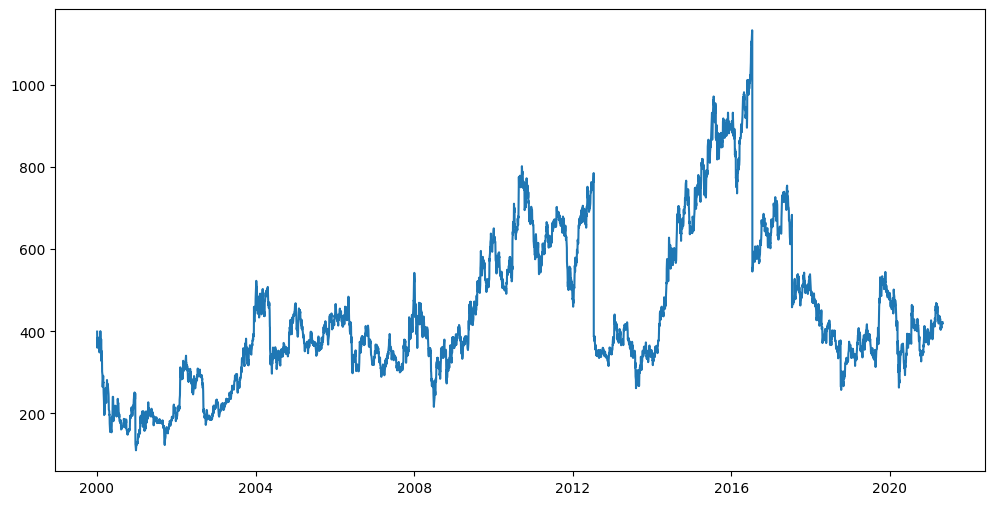

In [23]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'],df['Close'])


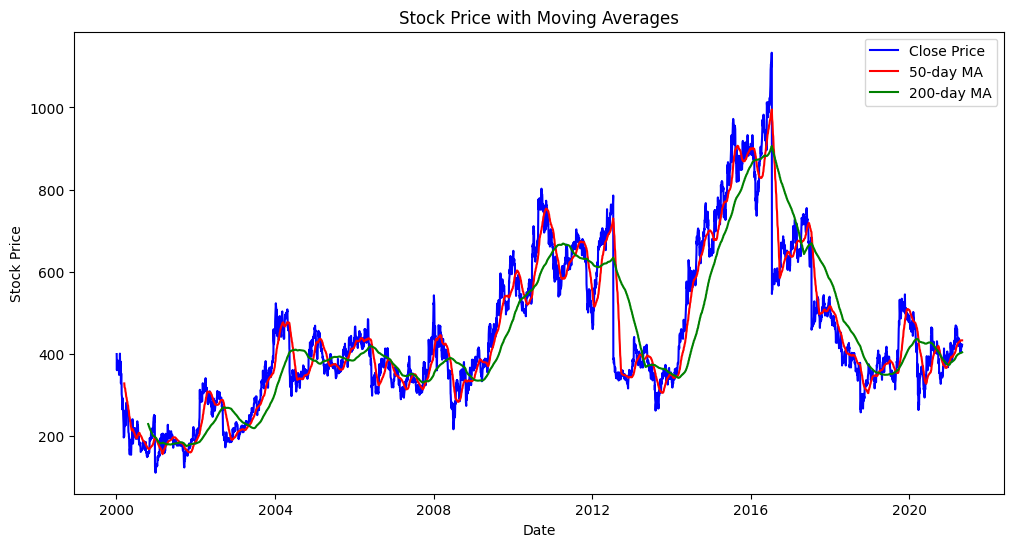

In [24]:
df['MA50'] = df['Close'].rolling(window=50).mean()  # 50-day Moving Average
df['MA200'] = df['Close'].rolling(window=200).mean()  # 200-day Moving Average

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')
plt.plot(df['Date'], df['MA50'], label='50-day MA', color='red')
plt.plot(df['Date'], df['MA200'], label='200-day MA', color='green')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price with Moving Averages')
plt.legend()
plt.show()


In [26]:
df['MA50'].unique()

array([    nan, 327.672, 323.944, ..., 432.593, 432.545, 432.619])

C:\Users\Asus\AppData\Local\Temp\ipykernel_26492\635479201.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm')


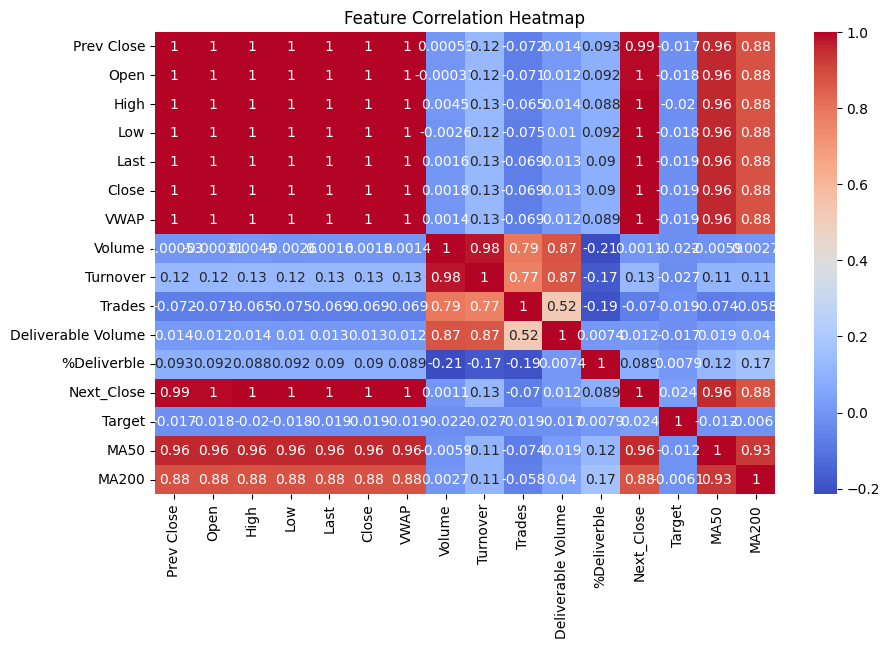

In [27]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


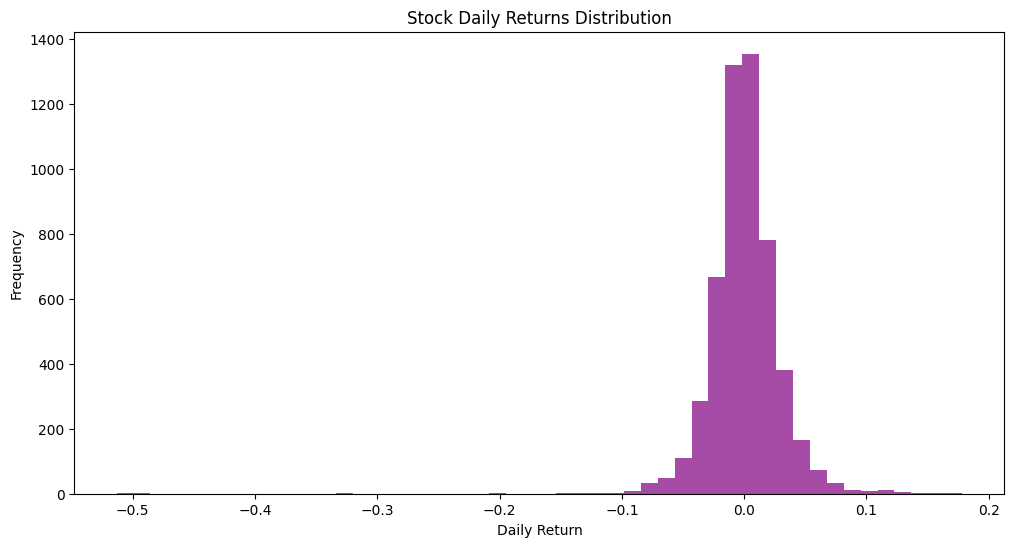

In [28]:
df['Daily Return'] = df['Close'].pct_change()

plt.figure(figsize=(12,6))
plt.hist(df['Daily Return'].dropna(), bins=50, color='purple', alpha=0.7)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.title('Stock Daily Returns Distribution')
plt.show()


In [29]:
df['Daily Return'] = df['Close'].pct_change()
df['Price Change'] = df['Close'] - df['Open']
df['High-Low'] = df['High'] - df['Low']
df['Volatility'] = df['Close'].rolling(window=10).std()


In [30]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,...,Deliverable Volume,%Deliverble,Next_Close,Target,MA50,MA200,Daily Return,Price Change,High-Low,Volatility
0,2000-01-03,BPCL,EQ,381.20,405.00,407.00,393.05,397.75,399.25,399.32,...,443175.0,0.4438,370.50,0,NaN,NaN,NaN,-5.75,13.95,NaN
1,2000-01-04,BPCL,EQ,399.25,397.75,397.75,367.40,377.45,370.50,375.71,...,443175.0,0.4438,359.95,0,NaN,NaN,-0.072010,-27.25,30.35,NaN
2,2000-01-05,BPCL,EQ,370.50,350.00,385.00,350.00,360.10,359.95,359.96,...,443175.0,0.4438,380.30,1,NaN,NaN,-0.028475,9.95,35.00,NaN
3,2000-01-06,BPCL,EQ,359.95,362.00,384.00,362.00,381.65,380.30,380.10,...,443175.0,0.4438,379.85,0,NaN,NaN,0.056536,18.30,22.00,NaN
4,2000-01-07,BPCL,EQ,380.30,369.00,390.00,366.00,381.50,379.85,378.33,...,443175.0,0.4438,384.95,1,NaN,NaN,-0.001183,10.85,24.00,NaN
